In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [65]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank0_1x_TD_Sweep_4.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_1x_TD_Sweep_4.npy")
arr_uncalib = np.concatenate((arr0, arr1), axis=1)
print(arr_uncalib.shape)

(65, 512)


In [66]:
arr0 = np.load("..\Data\Bank0_1x_TD_Sweep_4_Calib.npy")
arr1 = np.load("..\Data\Bank1_1x_TD_Sweep_4_Calib.npy")
arr_calib = np.concatenate((arr0, arr1), axis=1)
print(arr_calib.shape)

(65, 512)


In [67]:
print(arr0[0,0:64])
print(arr0[0,64:128])
print(arr0[0,128:192])
print(arr0[0,192:256])

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -2  0 -2 -1
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -2  0 -2 -1
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -2  0 -2 -1
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -2  0 -2 -1
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


C:\Users\dsdl\AppData\Local\Temp\ipykernel_14000\276371625.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Greens')
C:\Users\dsdl\AppData\Local\Temp\ipykernel_14000\276371625.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


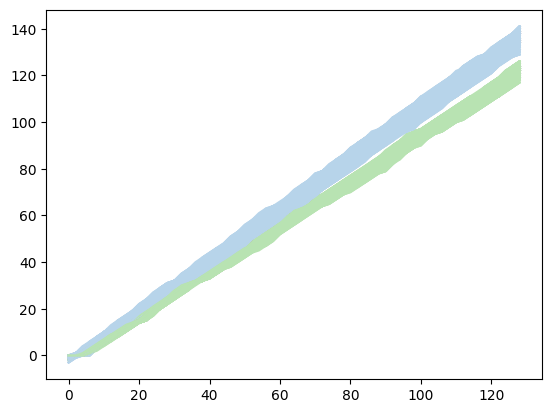

In [68]:
ideal_mac = list(range(0,129,2))
cmap2 = cm.get_cmap('Greens')
cmap = cm.get_cmap('Blues')
for i in range(0,arr_uncalib.shape[1],1):
    d1 = arr_uncalib[:,i]
    d2 = arr_calib[:,i]
    plt.plot(ideal_mac, d1, color = cmap(0.3))
    plt.plot(ideal_mac, d2, color = cmap2(0.3))


(65, 512)


C:\Users\dsdl\AppData\Local\Temp\ipykernel_14000\3675980307.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')
C:\Users\dsdl\AppData\Local\Temp\ipykernel_14000\3675980307.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Greens')


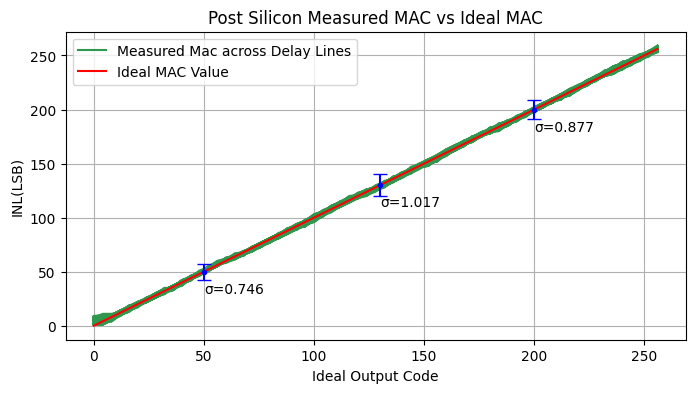

In [85]:
ideal_mac = list(range(0,257,4))
len(ideal_mac)
print(arr_uncalib.shape)
corrected = []
error = []
cmap = cm.get_cmap('Blues')
cmap2 = cm.get_cmap('Greens')
fig, ax = plt.subplots(figsize=(8, 4))
plt.title("Post Silicon Measured MAC vs Ideal MAC")
plt.xlabel("Ideal Output Code")
plt.ylabel("INL(LSB)")
slope = []
bias = []
for i in range(0,arr_uncalib.shape[1],1):
    d1 = arr_uncalib[:,i]
    m, c = np.polyfit(d1,ideal_mac , 1)
    slope.append(m)
    bias.append(c)
    d2 = np.round(d1*m+c)
    #plt.plot(ideal_mac, 2*d1, color = cmap(0.3))
    plt.plot(ideal_mac, d2, color = cmap2(0.7))
    corrected.append(d2)
    error.append(d2 - ideal_mac)
corrected = np.array(corrected)
for point in [50,130,200]:
    mean = np.mean(corrected[:,round(point/4)])
    std = np.std(corrected[:,round(point/4)])
    # Main plot arrow (pointing to feature of interest)
    ax.text(point,point-20,f'σ={std:0.3f}',
                fontsize=10)
    ax.errorbar(point, point, yerr=std*10, fmt='o', color='blue', capsize=5, markersize=3)
plt.plot(ideal_mac, d2, color = cmap2(0.7), label = "Measured Mac across Delay Lines")
plt.plot(ideal_mac, ideal_mac,color = "Red", label = "Ideal MAC Value")
plt.legend() 
plt.grid(True)
plt.show()

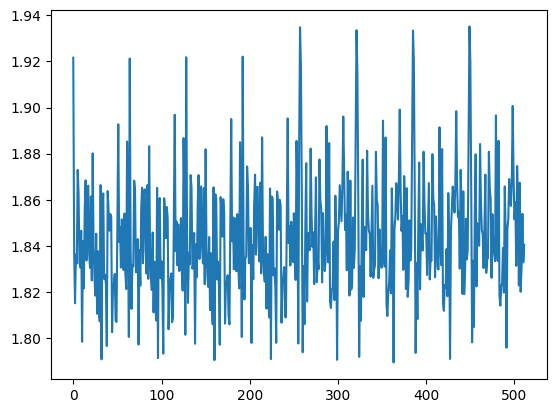

In [86]:
plt.plot(slope)
#plt.plot(bias)

(65, 512)


C:\Users\dsdl\AppData\Local\Temp\ipykernel_14000\2857954896.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')
C:\Users\dsdl\AppData\Local\Temp\ipykernel_14000\2857954896.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Greens')


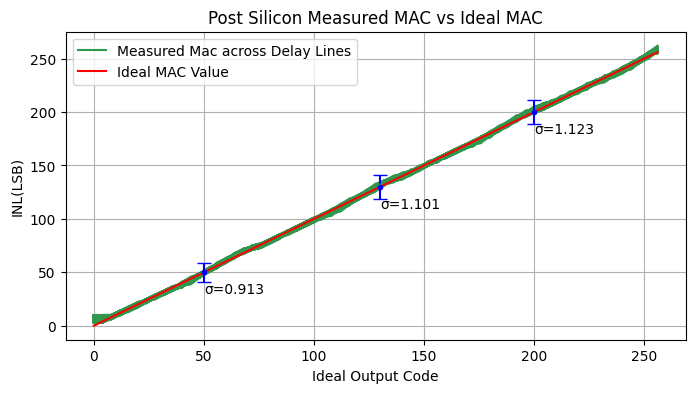

In [87]:
ideal_mac = list(range(0,257,4))
len(ideal_mac)
print(arr_calib.shape)
corrected = []
error = []
cmap = cm.get_cmap('Blues')
cmap2 = cm.get_cmap('Greens')
fig, ax = plt.subplots(figsize=(8, 4))
plt.title("Post Silicon Measured MAC vs Ideal MAC")
plt.xlabel("Ideal Output Code")
plt.ylabel("INL(LSB)")
slope = []
bias = []
for i in range(0,arr_calib.shape[1],1):
    d1 = arr_calib[:,i]
    m, c = np.polyfit(d1,ideal_mac , 1)
    slope.append(m)
    bias.append(c)
    d2 = np.round(d1*m+c)
    #plt.plot(ideal_mac, 2*d1, color = cmap(0.3))
    plt.plot(ideal_mac, d2, color = cmap2(0.7))
    corrected.append(d2)
    error.append(d2 - ideal_mac)
corrected = np.array(corrected)
for point in [50,130,200]:
    mean = np.mean(corrected[:,round(point/4)])
    std = np.std(corrected[:,round(point/4)])
    # Main plot arrow (pointing to feature of interest)
    ax.text(point,point-20,f'σ={std:0.3f}',
                fontsize=10)
    ax.errorbar(point, point, yerr=std*10, fmt='o', color='blue', capsize=5, markersize=3)
plt.plot(ideal_mac, d2, color = cmap2(0.7), label = "Measured Mac across Delay Lines")
plt.plot(ideal_mac, ideal_mac,color = "Red", label = "Ideal MAC Value")
plt.legend() 
plt.grid(True)
plt.show()

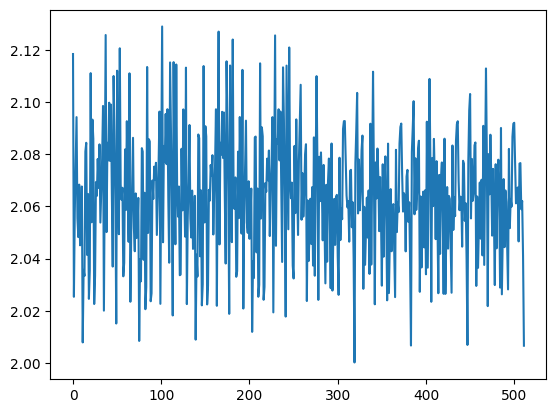

In [88]:
plt.plot(slope)
#plt.plot(bias)